---

<center>

# **Proyecto Final: Ecuaciones Parabolicas en 2D con Elemntos Finitos**

**Realizado por:**

Samuel Huertas Rojas

</center>

---

In [8]:
import pygmsh
import meshio
from math import pi, cos

import pyvista as pv

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.tri import Triangulation
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

In [11]:
with pygmsh.occ.Geometry() as geom:
    geom.add_polygon(
        [
            [0.0, 0.0],
            [0.0, 2],
            [2, 2],
            [2, 0.0],
        ],
        mesh_size=0.1,
    )

    # geom.characteristic_length_max = 0.1
    # r = 0.5
    # disks = [
    #     geom.add_disk([-0.5 * cos(7 / 6 * pi), -0.25], 1.0),
    #     geom.add_disk([+0.5 * cos(7 / 6 * pi), -0.25], 1.0),
    #     geom.add_disk([0.0, 0.5], 1.0),
    # ]
    # geom.boolean_intersection(disks)

    mesh = geom.generate_mesh()

# Ver información del mallado
print(f"Número de puntos: {len(mesh.points)}")
print(f"Número de celdas: {len(mesh.cells)}")

# Guardar o visualizar
meshio.write("mesh.vtk", mesh)

Número de puntos: 510
Número de celdas: 3


c:\Users\samhu\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


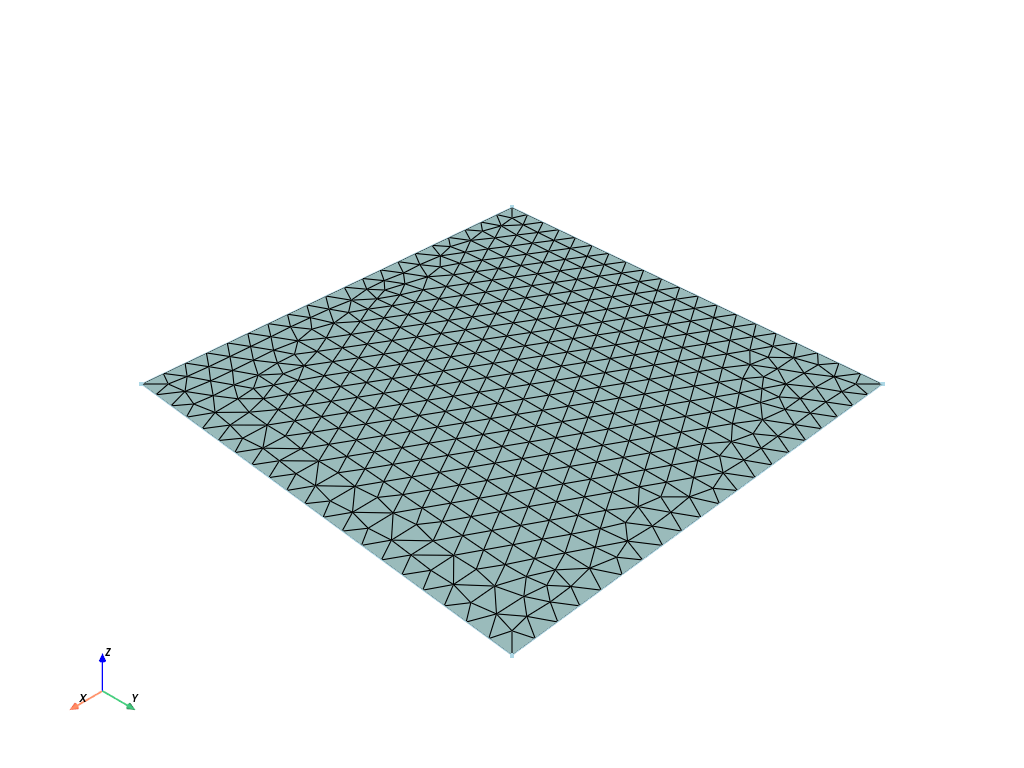

In [12]:
# Visualizar con PyVista
mesh_pv = pv.read("mesh.vtk")
mesh_pv.plot(show_edges=True, color='lightblue', line_width=1)

In [19]:
class HeatEquationFEMFromVTK:
    """
    Resuelve la ecuación de conducción de calor en 2D usando mallado 
    triangular cargado desde archivo VTK con condiciones de frontera personalizables.
    
    Ecuación del calor: ρc ∂T/∂t = k(∂²T/∂x² + ∂²T/∂y²) + Q(x,y,t)
    """
    
    def __init__(self, vtk_file, T, nt, material='acero'):
        """
        Parámetros:
        - vtk_file: ruta al archivo .vtk con el mallado
        - T: tiempo final de simulación [s]
        - nt: número de pasos temporales
        - material: tipo de material
        """
        self.T = T
        self.nt = nt
        
        # Cargar mallado desde VTK
        print(f"Cargando mallado desde {vtk_file}...")
        self.load_mesh_from_vtk(vtk_file)
        
        # Propiedades térmicas del material
        self.set_material(material)
        self.alpha = self.k_thermal / (self.rho * self.c)
        
        # Malla temporal
        self.t = np.linspace(0, T, nt)
        self.dt = T / (nt - 1)
        
        # Historia de temperaturas
        self.T_history = []
        
        # Funciones de condiciones de frontera e iniciales (por defecto)
        self.initial_temp_func = self.default_initial_temperature
        self.boundary_temp_func = self.default_boundary_temperature
        self.heat_source_func = self.default_heat_source
        self.boundary_condition_func = self.dirichlet_condition
        
        print(f"Material: {self.material_name}")
        print(f"Difusividad térmica α = {self.alpha:.2e} m²/s")
        print(f"Mallado: {self.N} nodos → {len(self.triangles)} triángulos")
        print(f"Tiempo de simulación: {T} s")
    
    def load_mesh_from_vtk(self, vtk_file):
        """Carga el mallado desde un archivo VTK"""
        mesh = meshio.read(vtk_file)
        
        # Extraer nodos (solo coordenadas x, y)
        self.nodes = mesh.points[:, :2]
        self.N = len(self.nodes)
        
        # Extraer triángulos
        self.triangles = None
        for cell_block in mesh.cells:
            if cell_block.type == "triangle":
                self.triangles = cell_block.data
                break
        
        if self.triangles is None:
            raise ValueError("El archivo VTK no contiene elementos triangulares")
        
        # Crear objeto Triangulation para matplotlib
        self.tri = Triangulation(self.nodes[:, 0], self.nodes[:, 1], self.triangles)
        
        # Calcular bounding box
        self.x_min, self.y_min = self.nodes.min(axis=0)
        self.x_max, self.y_max = self.nodes.max(axis=0)
        self.Lx = self.x_max - self.x_min
        self.Ly = self.y_max - self.y_min
        
        print(f"  Nodos: {self.N}")
        print(f"  Triángulos: {len(self.triangles)}")
        print(f"  Dominio: x ∈ [{self.x_min:.3f}, {self.x_max:.3f}], "
              f"y ∈ [{self.y_min:.3f}, {self.y_max:.3f}]")
        
        # Identificar nodos de frontera (automáticamente)
        self.identify_boundary_nodes()
    
    def identify_boundary_nodes(self):
        """Identifica nodos que están en la frontera del dominio"""
        # Contar cuántas veces aparece cada arista
        edge_count = {}
        
        for tri in self.triangles:
            edges = [(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])]
            for edge in edges:
                # Normalizar arista (menor índice primero)
                edge_norm = tuple(sorted(edge))
                edge_count[edge_norm] = edge_count.get(edge_norm, 0) + 1
        
        # Aristas de frontera aparecen solo una vez
        boundary_edges = [edge for edge, count in edge_count.items() if count == 1]
        
        # Extraer nodos únicos de las aristas de frontera
        self.boundary_nodes = set()
        for edge in boundary_edges:
            self.boundary_nodes.add(edge[0])
            self.boundary_nodes.add(edge[1])
        
        print(f"  Nodos de frontera: {len(self.boundary_nodes)}")
    
    def set_material(self, material):
        """Define propiedades térmicas del material"""
        materials = {
            'acero': {'name': 'Acero', 'rho': 7850, 'c': 490, 'k': 50.2},
            'aluminio': {'name': 'Aluminio', 'rho': 2700, 'c': 897, 'k': 237},
            'cobre': {'name': 'Cobre', 'rho': 8960, 'c': 385, 'k': 401},
            'concreto': {'name': 'Concreto', 'rho': 2300, 'c': 880, 'k': 1.4}
        }
        
        mat = materials.get(material, materials['acero'])
        self.material_name = mat['name']
        self.rho = mat['rho']
        self.c = mat['c']
        self.k_thermal = mat['k']
    
    # ========== CONDICIONES POR DEFECTO ==========
    
    def default_initial_temperature(self, x, y):
        """Temperatura inicial por defecto: fuente de calor en el centro"""
        T_ambient = 20.0
        x_center = (self.x_min + self.x_max) / 2
        y_center = (self.y_min + self.y_max) / 2
        radius = min(self.Lx, self.Ly) / 6
        dist = np.sqrt((x - x_center)**2 + (y - y_center)**2)
        
        if dist < radius:
            T_hot = 200.0
            return T_ambient + (T_hot - T_ambient) * (1 - dist/radius)
        return T_ambient
    
    def default_boundary_temperature(self, x, y, t):
        return 0
    
    def default_heat_source(self, x, y, t):
        """Fuente de calor por defecto: sin fuente"""
        return 2
    
    def dirichlet_condition(self, x, y):
        """
        Determina si un nodo está en la frontera donde aplicar Dirichlet.
        Por defecto: toda la frontera
        Retorna True si se aplica condición de Dirichlet
        """
        return True
    
    # ========== MÉTODOS PARA PERSONALIZAR CONDICIONES ==========
    
    def set_initial_temperature(self, func):
        """
        Define condición inicial personalizada.
        func debe ser: T = func(x, y) que retorna temperatura en °C
        """
        self.initial_temp_func = func
    
    def set_boundary_temperature(self, func):
        """
        Define temperatura de frontera personalizada.
        func debe ser: T = func(x, y, t) que retorna temperatura en °C
        """
        self.boundary_temp_func = func
    
    def set_heat_source(self, func):
        """
        Define fuente de calor personalizada.
        func debe ser: Q = func(x, y, t) que retorna W/m³
        
        Ejemplo:
        def mi_fuente(x, y, t):
            return 1e6 if np.sqrt(x**2 + y**2) < 0.1 else 0.0
        solver.set_heat_source(mi_fuente)
        """
        self.heat_source_func = func
    
    def apply_custom_boundary_condition(self):
        """Aplica la función personalizada de condición de frontera"""
        self.dirichlet_nodes = set()
        for idx in self.boundary_nodes:
            x, y = self.nodes[idx]
            if self.dirichlet_condition(x, y):
                self.dirichlet_nodes.add(idx)
        print(f"  Nodos con condición Dirichlet: {len(self.dirichlet_nodes)}")
    
    # ========== MÉTODOS DE ELEMENTOS FINITOS ==========
    
    def compute_triangle_area(self, triangle):
        """Calcula el área de un triángulo"""
        p0, p1, p2 = self.nodes[triangle]
        area = abs((p1[0]-p0[0])*(p2[1]-p0[1]) - (p2[0]-p0[0])*(p1[1]-p0[1])) / 2
        return area
    
    def compute_gradients(self, triangle):
        """Calcula los gradientes de las funciones techo en un triángulo"""
        p0, p1, p2 = self.nodes[triangle]
        x0, y0 = p0
        x1, y1 = p1
        x2, y2 = p2
        
        area_2 = (x1-x0)*(y2-y0) - (x2-x0)*(y1-y0)
        
        gradients = np.zeros((3, 2))
        gradients[0, 0] = (y1 - y2) / area_2
        gradients[0, 1] = (x2 - x1) / area_2
        gradients[1, 0] = (y2 - y0) / area_2
        gradients[1, 1] = (x0 - x2) / area_2
        gradients[2, 0] = (y0 - y1) / area_2
        gradients[2, 1] = (x1 - x0) / area_2
        
        return gradients
    
    def assemble_matrices(self):
        """Ensambla matrices de masa y rigidez"""
        M = lil_matrix((self.N, self.N))
        K = lil_matrix((self.N, self.N))
        
        for tri_nodes in self.triangles:
            area = self.compute_triangle_area(tri_nodes)
            gradients = self.compute_gradients(tri_nodes)
            
            # Matriz de masa local
            m_local = (self.rho * self.c * area / 12) * np.array([
                [2, 1, 1],
                [1, 2, 1],
                [1, 1, 2]
            ])
            
            # Matriz de rigidez local
            k_local = np.zeros((3, 3))
            for i in range(3):
                for j in range(3):
                    k_local[i, j] = self.k_thermal * area * np.dot(gradients[i], gradients[j])
            
            # Ensamblar
            for i in range(3):
                for j in range(3):
                    M[tri_nodes[i], tri_nodes[j]] += m_local[i, j]
                    K[tri_nodes[i], tri_nodes[j]] += k_local[i, j]
        
        return csr_matrix(M), csr_matrix(K)
    
    def solve(self):
        """Resuelve la ecuación del calor usando esquema regresivo"""
        print("\nEnsamblando matrices FEM...")
        M, K = self.assemble_matrices()
        
        # Temperatura inicial
        T = np.zeros(self.N)
        for idx in range(self.N):
            x, y = self.nodes[idx]
            T[idx] = self.initial_temp_func(x, y)
        
        self.T_history.append(T.copy())

        # Aplicar condición de frontera personalizada
        if not hasattr(self, 'dirichlet_nodes'):
            self.dirichlet_nodes = self.boundary_nodes.copy()
        
        # Lado izquierdo: (M + Δt·K)
        A_left = M + self.dt * K
        
        print(f"Resolviendo {self.nt} pasos temporales (Backward Euler)...")
        
        for n in range(1, self.nt):
            t_current = self.t[n]
            
            # Vector de fuentes
            Q = np.zeros(self.N)
            for idx in range(self.N):
                x, y = self.nodes[idx]
                Q[idx] = self.heat_source_func(x, y, t_current)
            
            # Lado derecho
            b = M @ T + self.dt * Q
            
            # Aplicar condiciones de frontera
            A_left_copy = A_left.tolil()
            b_copy = b.copy()
            
            for idx in self.dirichlet_nodes:
                x, y = self.nodes[idx]
                T_bc = self.boundary_temp_func(x, y, t_current)
                
                penalty = 1e10
                A_left_copy[idx, idx] = penalty
                b_copy[idx] = penalty * T_bc
                
                for k in range(self.N):
                    if k != idx:
                        A_left_copy[idx, k] = 0
            
            # Resolver
            T = spsolve(csr_matrix(A_left_copy), b_copy)
            self.T_history.append(T.copy())
            
            if (n % max(1, self.nt // 10)) == 0:
                T_min, T_max = T.min(), T.max()
                print(f"  t = {t_current:.3f}s | T_min = {T_min:.1f}°C, T_max = {T_max:.1f}°C")
        
        print("¡Simulación completada!")
    
    def plot_mesh(self):
        """Visualiza el mallado"""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        ax.triplot(self.tri, 'k-', linewidth=0.5, alpha=0.5)
        ax.plot(self.nodes[:, 0], self.nodes[:, 1], 'b.', markersize=2)
        
        # Resaltar nodos de frontera
        boundary_coords = self.nodes[list(self.boundary_nodes)]
        ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 'ro', 
                markersize=4, label='Nodos de frontera')
        
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        ax.set_title(f'Mallado: {self.N} nodos, {len(self.triangles)} triángulos')
        ax.set_aspect('equal')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def animate(self, interval=50, save_as=None):
        """Anima la propagación del calor"""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        T_min = min(T.min() for T in self.T_history)
        T_max = max(T.max() for T in self.T_history)
        
        im = ax.tripcolor(self.tri, self.T_history[0], 
                         cmap='hot', vmin=T_min, vmax=T_max, shading='gouraud')
        ax.triplot(self.tri, 'k-', linewidth=0.3, alpha=0.2)
        cbar = plt.colorbar(im, ax=ax, label='Temperatura [°C]')
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        ax.set_aspect('equal')
        
        title = ax.set_title(f'{self.material_name} | t = {self.t[0]:.3f}s', 
                            fontsize=14, fontweight='bold')
        
        def update(frame):
            im.set_array(self.T_history[frame])
            title.set_text(f'{self.material_name} | t = {self.t[frame]:.3f}s')
            return im, title
        
        anim = FuncAnimation(fig, update, frames=len(self.T_history),
                           interval=interval, blit=False)
        
        if save_as:
            anim.save(save_as, writer='pillow', fps=20)
            print(f"Animación guardada como {save_as}")
        
        plt.tight_layout()
        plt.show()

Cargando mallado desde mesh.vtk...
  Nodos: 510
  Triángulos: 938
  Dominio: x ∈ [0.000, 2.000], y ∈ [0.000, 2.000]
  Nodos de frontera: 80
Material: Aluminio
Difusividad térmica α = 9.79e-05 m²/s
Mallado: 510 nodos → 938 triángulos
Tiempo de simulación: 30.0 s


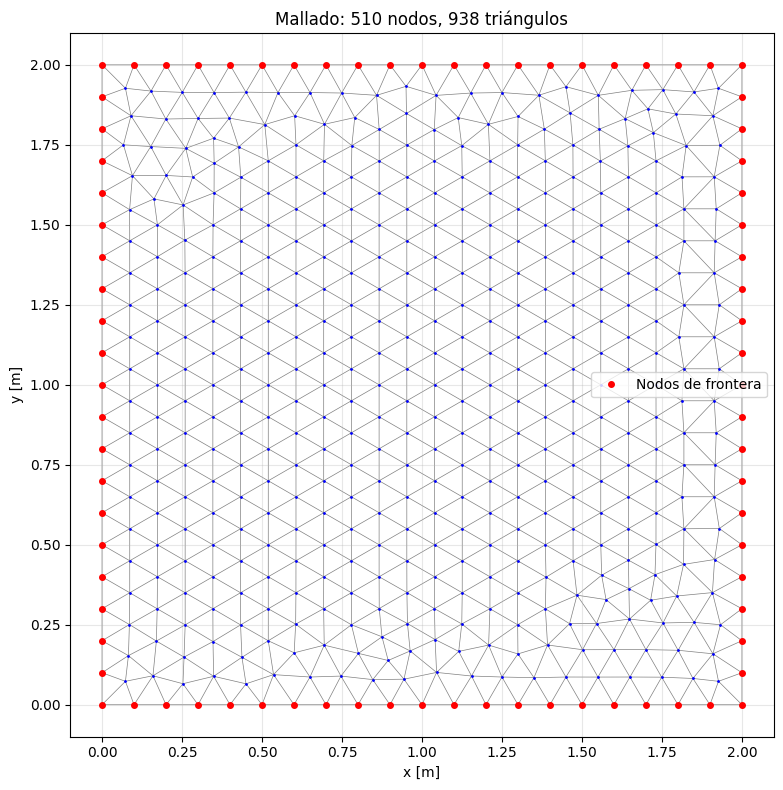


Ensamblando matrices FEM...
Resolviendo 100 pasos temporales (Backward Euler)...
  t = 3.030s | T_min = 0.0°C, T_max = 172.9°C
  t = 6.061s | T_min = 0.0°C, T_max = 167.9°C
  t = 9.091s | T_min = 0.0°C, T_max = 163.6°C
  t = 12.121s | T_min = 0.0°C, T_max = 159.9°C
  t = 15.152s | T_min = 0.0°C, T_max = 156.5°C
  t = 18.182s | T_min = 0.0°C, T_max = 153.3°C
  t = 21.212s | T_min = 0.0°C, T_max = 150.4°C
  t = 24.242s | T_min = 0.0°C, T_max = 147.7°C
  t = 27.273s | T_min = 0.0°C, T_max = 145.1°C
¡Simulación completada!
Animación guardada como heat_propagation.gif


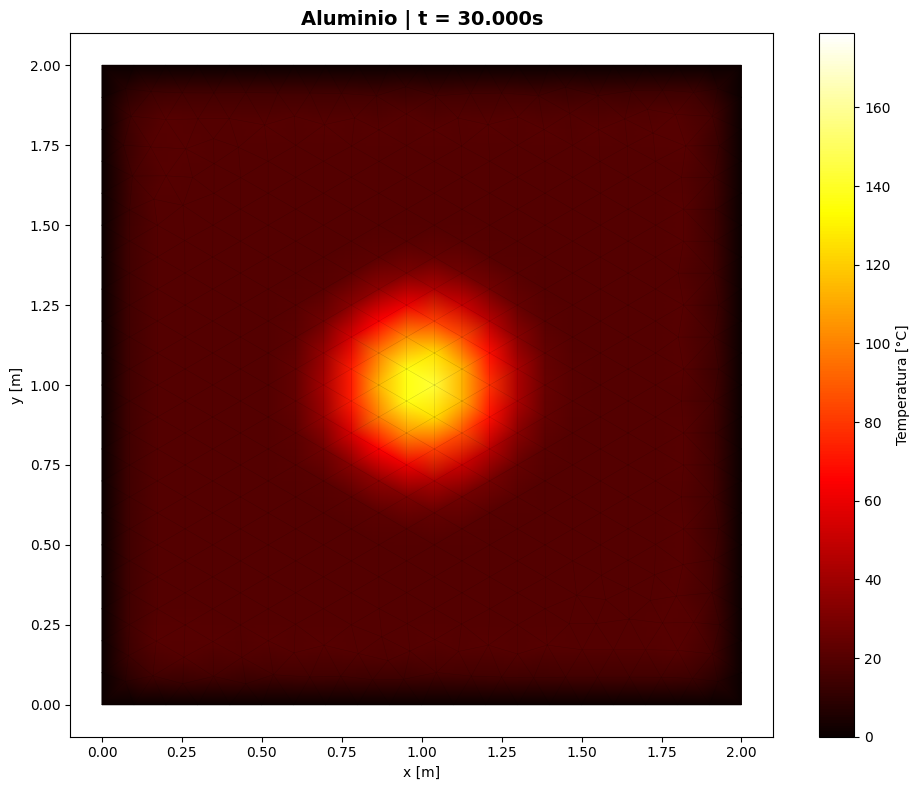

In [20]:
# Crear solver cargando geometría desde VTK
solver = HeatEquationFEMFromVTK(
    vtk_file='mesh.vtk',
    T=30.0,
    nt=100,
    material='aluminio'
)

solver.plot_mesh()
solver.solve()
solver.animate(interval=50, save_as='heat_propagation.gif')
